# Fab Operations Analytics — Root-Cause Investigation

**A yield excursion, traced end to end in SQL.**

This notebook walks the standard investigation arc a yield / process-integration
engineer runs during an excursion:

> **symptom → suspect → confirm (independent signals) → size the impact → exposure → recommendation**

The data is a **synthetic 300-wafer fab dataset** (`seed=42`). It is built to contain
*one* discoverable root cause; nothing here is a real-world benchmark. The point of the
project is the **method and the SQL**, not the numbers.

In [1]:
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Requires the package install: pip install -e ".[notebook]"
from fabops.db import run_query, run_view
from fabops import charts

SUSPECT = "ETCH-02"
print("data layer ready")

data layer ready


## Step 1 — Symptom

Start where the business does: **products are missing their yield targets.** The
`v_yield_by_product` view compares actual vs target yield per product.

In [2]:
run_view("v_yield_by_product", order_by="gap_to_target")

,product_name,target_yield_pct,actual_yield,gap_to_target,wafers
0,AI-14,68.0,58.11,-9.89,50
1,Logic-180,92.0,82.27,-9.73,25
2,Logic-90,88.0,78.57,-9.43,49
3,RF-45,80.0,70.76,-9.24,25
4,SRAM-65,85.0,76.22,-8.78,25
5,Mobile-28,75.0,66.52,-8.48,49


Every product sits ~8–10 points below target, and the deficit is strikingly **uniform**.
A product-specific cause (design, a single layer) would hit some products far harder than
others. Uniform loss across the catalogue points instead to **shared infrastructure** — a
tool every lot passes through.

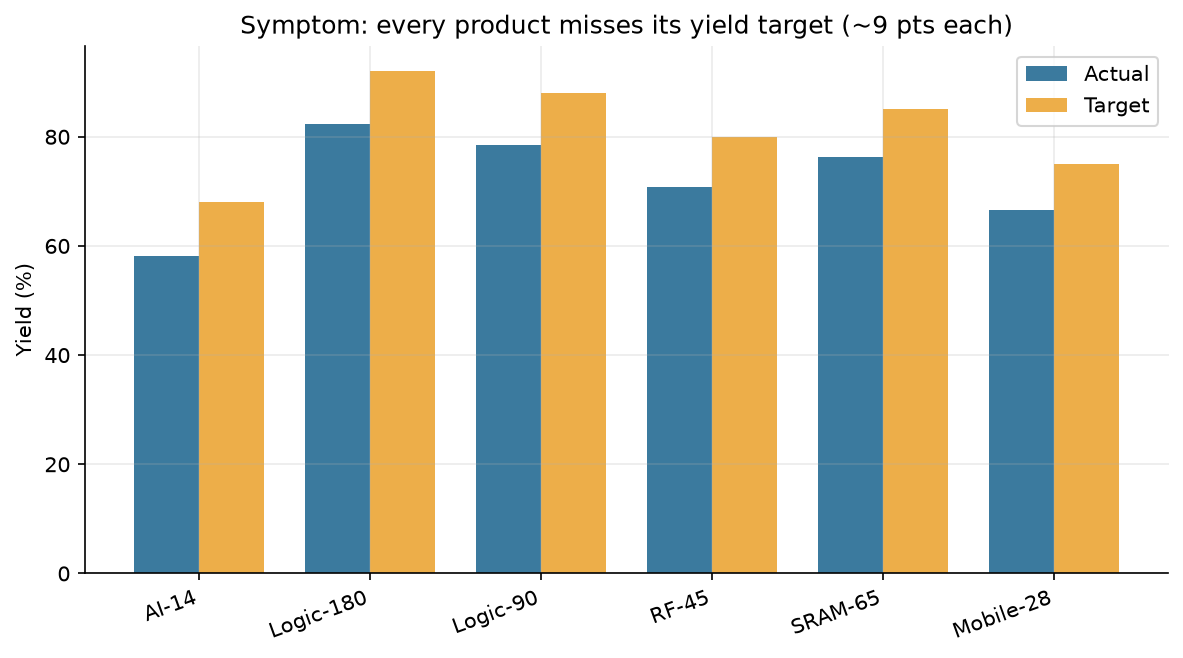

In [3]:
display(Image(charts.chart_product_gap()))

## Step 2 — Suspect

Gate etch (step 4) is a shared, yield-critical step. Split gate-etch yield by the **tool**
each wafer was processed on.

In [4]:
run_view("v_etch_tool_yield", order_by="avg_yield")

,tool_name,wafers,avg_yield
0,ETCH-02,117,64.29
1,ETCH-03,55,75.91
2,ETCH-01,51,79.39


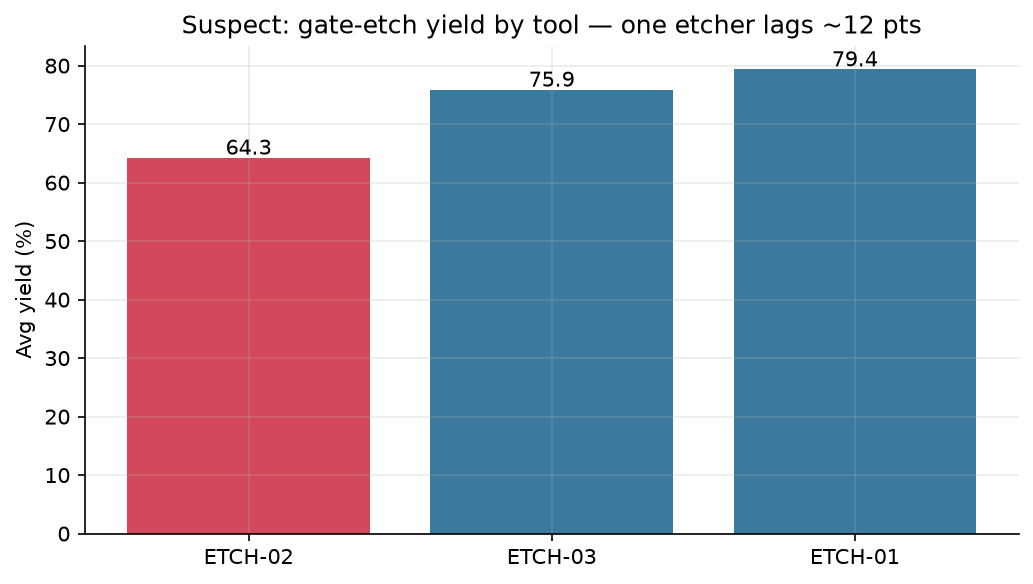

In [5]:
display(Image(charts.chart_tool_yield()))

**ETCH-02 yields ~12 points below the best etcher on the same step.** That is our prime
suspect. But a yield gap alone isn't proof — we need independent signals that agree.

## Step 3 — Confirmation #1: defect signature

If ETCH-02 is genuinely faulty, its wafers should carry a **distinctive defect type**.
Edge-ring defects are the classic fingerprint of an etch-chamber problem (edge non-uniformity,
clamp/temperature issues, edge-plasma effects).

In [6]:
run_view("v_edge_ring_by_tool", order_by="edge_ring_pct DESC")

,tool_name,total_defects,edge_ring_defects,edge_ring_pct
0,ETCH-02,5335,2333,43.7
1,ETCH-01,995,138,13.9
2,ETCH-03,1036,91,8.8


ETCH-02's defects are roughly **3× more edge-ring** than the other etchers'. The defect
*physics* agrees with the yield signal.

### Confirmation #1b: it's a *spatial* (radial) signature

Edge-ring isn't just a label — those defects should sit physically at the **wafer edge**.
The `v_defect_zone` view classifies every defect by radius (center / mid / edge). Compare the
mean defect radius and edge-zone share for suspect vs. other wafers.

In [7]:
run_query('''
    WITH tagged AS (
      SELECT DISTINCT y.wafer_id,
             MAX(CASE WHEN g.tool_name=? THEN 1 ELSE 0 END)
                 OVER (PARTITION BY y.wafer_id) AS on_suspect
      FROM yield_data y
      JOIN v_gate_etch_runs g ON g.wafer_id=y.wafer_id)
    SELECT CASE tg.on_suspect WHEN 1 THEN ? ELSE 'other etchers' END AS tool_group,
           COUNT(*) AS defects,
           ROUND(AVG(dz.radius_mm),1) AS avg_radius_mm,
           ROUND(100.0*SUM(CASE WHEN dz.zone='edge' THEN 1 ELSE 0 END)/COUNT(*),1) AS edge_zone_pct
    FROM tagged tg JOIN v_defect_zone dz ON dz.wafer_id=tg.wafer_id
    GROUP BY tg.on_suspect ORDER BY avg_radius_mm DESC
''', params=(SUSPECT, SUSPECT))

,tool_group,defects,avg_radius_mm,edge_zone_pct
0,ETCH-02,4718,106.7,61.5
1,other etchers,1848,85.0,38.6


The wafer maps make it unmistakable — a dense red edge ring on ETCH-02 wafers, only baseline
scatter elsewhere:

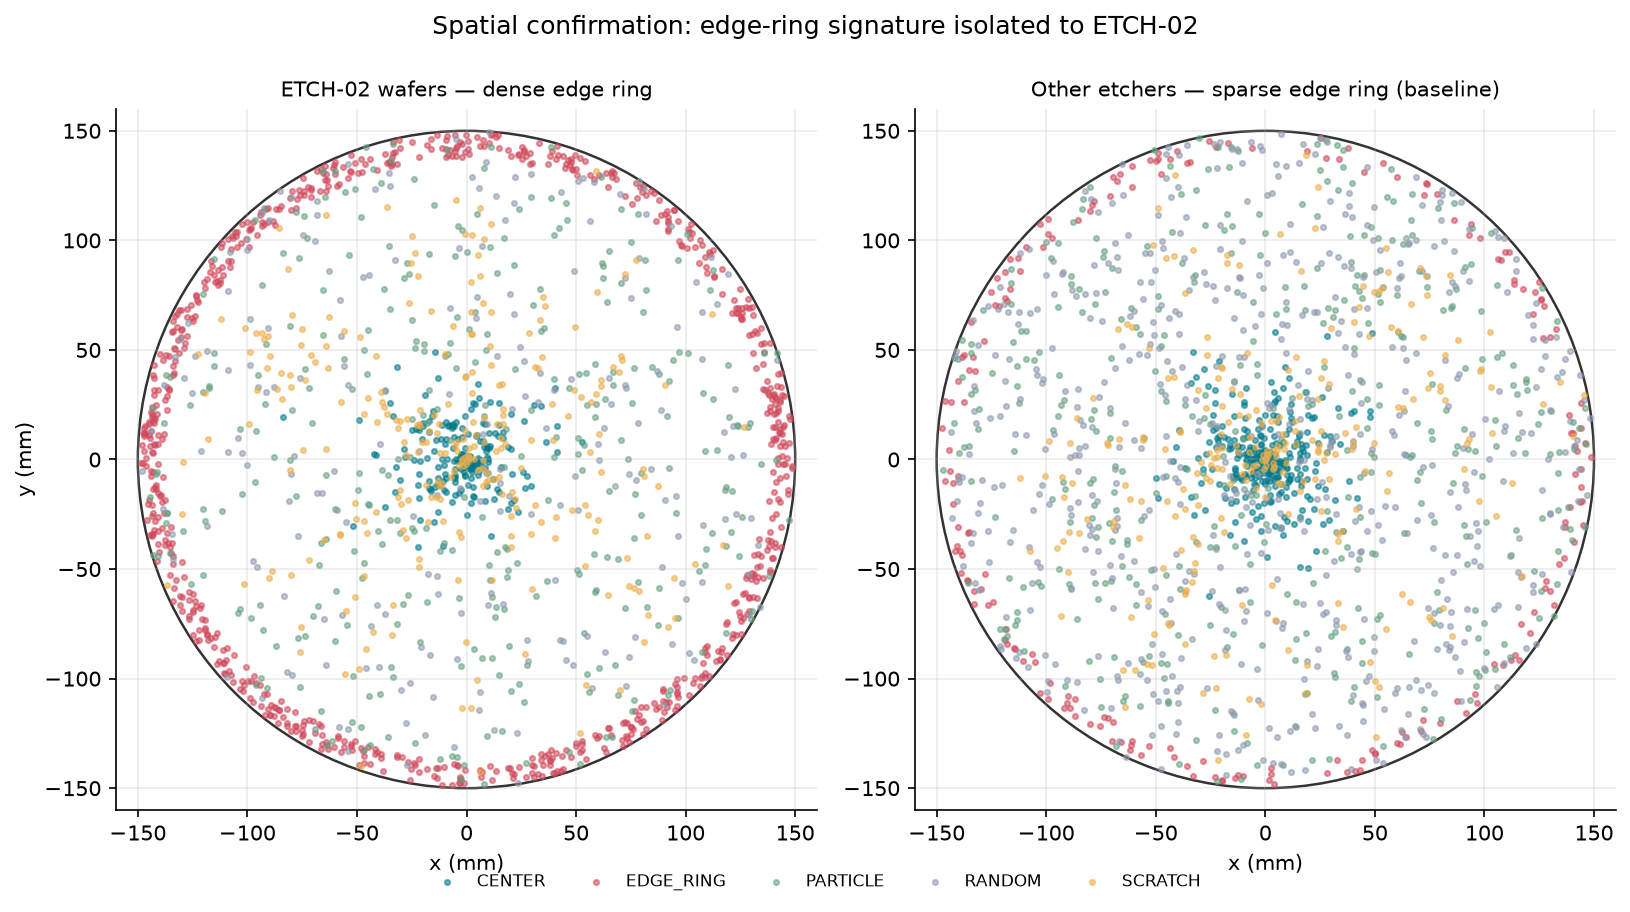

In [8]:
display(Image(charts.chart_wafer_maps()))

## Step 4 — Confirmation #2: an independent root signal

Defects and yield both come from the *measurement* side. For a second, **independent**
line of evidence, look at the **maintenance** log: a chamber drifting out of spec also breaks
down more often.

In [9]:
run_query('''
    SELECT tool_name, unscheduled_hrs, unscheduled_events, pm_hrs
    FROM v_tool_downtime WHERE tool_type='ETCH'
    ORDER BY unscheduled_hrs DESC
''')

,tool_name,unscheduled_hrs,unscheduled_events,pm_hrs
0,ETCH-02,30.53,4,23.07
1,ETCH-01,0.00,0,30.51
2,ETCH-03,0.00,0,24.85


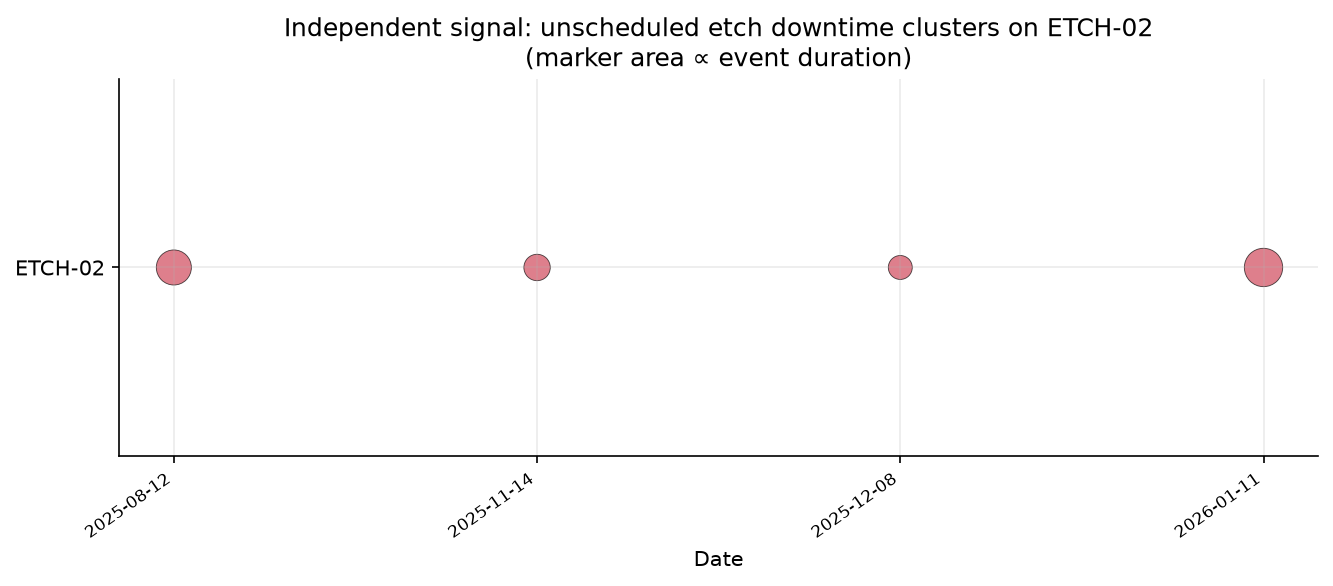

In [10]:
display(Image(charts.chart_downtime_timeline()))

ETCH-02 carries **all** of the unscheduled etch downtime; the other etchers have none. Two
independent data sources — defect inspection and equipment maintenance — name the **same tool**.

## Step 5 — Convergence

One scorecard, three signals. The finding is the **convergence**: the same tool is worst on
yield, highest on edge-ring %, and highest on unscheduled downtime.

In [11]:
run_view("v_tool_rca", order_by="edge_ring_pct DESC")

,tool_name,avg_yield,edge_ring_pct,unscheduled_hrs,unscheduled_events,wafers_processed
0,ETCH-02,64.29,43.7,30.53,4,154
1,ETCH-01,79.39,13.9,0.00,0,74
2,ETCH-03,75.91,8.8,0.00,0,72


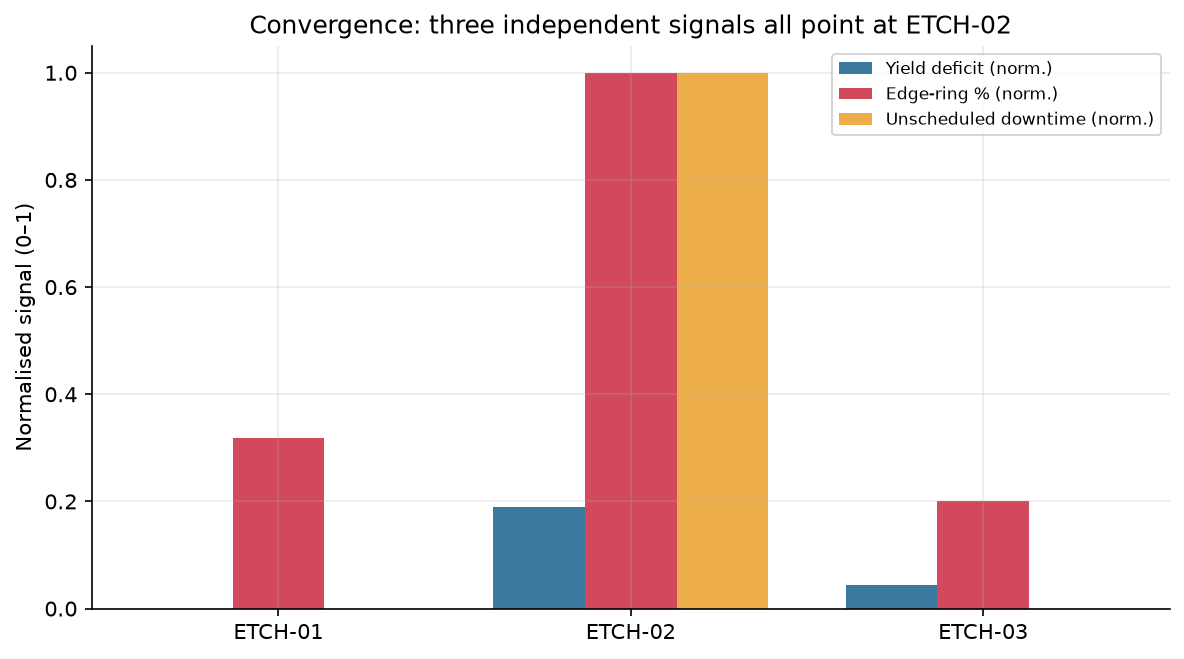

In [12]:
display(Image(charts.chart_rca_scorecard()))

## Step 6 — Size the impact

Quantify the cost: average yield on the suspect vs. the good etchers, and the estimated extra
good die we would have recovered had the suspect's wafers matched the others. *(Synthetic-data
estimate — illustrative of the method, not a real figure.)*

In [13]:
run_query('''
    WITH tagged AS (
      SELECT y.wafer_id, y.yield_pct, y.total_die,
             MAX(CASE WHEN g.tool_name=? THEN 1 ELSE 0 END) AS on_suspect
      FROM yield_data y
      JOIN v_gate_etch_runs g ON g.wafer_id=y.wafer_id
      GROUP BY y.wafer_id, y.yield_pct, y.total_die),
    benchmark AS (SELECT AVG(yield_pct) AS good_yield FROM tagged WHERE on_suspect=0)
    SELECT
      SUM(CASE WHEN on_suspect=1 THEN 1 ELSE 0 END) AS suspect_wafers,
      ROUND(AVG(CASE WHEN on_suspect=1 THEN yield_pct END),2) AS suspect_avg_yield,
      ROUND((SELECT good_yield FROM benchmark),2) AS good_etcher_yield,
      ROUND(SUM(CASE WHEN on_suspect=1
            THEN total_die*((SELECT good_yield FROM benchmark)-yield_pct)/100.0
            ELSE 0 END)) AS est_good_die_lost
    FROM tagged
''', params=(SUSPECT,))

,suspect_wafers,suspect_avg_yield,good_etcher_yield,est_good_die_lost
0,117,64.29,77.59,46575.0


## Step 7 — Exposure

For containment, find the lots most dependent on the suspect chamber so re-inspection can be
prioritised.

In [14]:
run_query('''
    WITH per_lot AS (
      SELECT l.lot_number,
             COUNT(DISTINCT g.wafer_id) AS gate_etch_wafers,
             COUNT(DISTINCT CASE WHEN g.tool_name=? THEN g.wafer_id END) AS on_suspect
      FROM v_gate_etch_runs g
      JOIN wafers w ON w.wafer_id=g.wafer_id
      JOIN lots l ON l.lot_id=w.lot_id
      WHERE g.tool_type='ETCH'
      GROUP BY l.lot_number)
    SELECT lot_number, on_suspect, gate_etch_wafers,
           ROUND(100.0*on_suspect/gate_etch_wafers,1) AS pct_on_suspect
    FROM per_lot ORDER BY pct_on_suspect DESC
''', params=(SUSPECT,))

,lot_number,on_suspect,gate_etch_wafers,pct_on_suspect
0,LOT2025006,16,25,64.0
1,LOT2025010,16,25,64.0
2,LOT2025002,15,25,60.0
3,LOT2025005,15,25,60.0
4,LOT2025004,14,25,56.0
5,LOT2025001,13,25,52.0
6,LOT2025009,13,25,52.0
7,LOT2025012,13,25,52.0
8,LOT2025007,12,25,48.0
9,LOT2025003,11,25,44.0


## Recommendation

1. **Take ETCH-02 offline for chamber inspection.** The edge-ring signature plus the
   unscheduled-downtime cluster points to an edge-uniformity / clamp fault.
2. **Contain.** Re-inspect the high-exposure lots above; reroute in-flight gate-etch to
   ETCH-01 / ETCH-03 until ETCH-02 is re-qualified.
3. **Prevent.** Add an SPC rule on per-chamber gate-etch edge-ring fraction so the next drift
   trips an alarm instead of surfacing in a yield post-mortem.

**Method demonstrated:** symptom isolation → suspect identification → two *independent*
confirmations (defect physics + maintenance) → quantified loss → exposure sizing → action.
That arc — not any single query — is what a yield/process-data interview is really testing.

---
*Synthetic data, `seed=42`. Reproduce everything with `python -m fabops.investigation`.*